In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Files in current directory:")
print(os.listdir())

df = pd.read_csv("mail_data.csv")

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

df.head()

Files in current directory:
['.config', 'mail_data.csv', '.ipynb_checkpoints', 'sample_data']

Dataset Shape:
(5572, 2)

Columns:
Index(['Category', 'Message'], dtype='object')


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [33]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicates:")
print(df.duplicated().sum())

print("\nClass counts:")
print(df["Category"].value_counts())

Shape: (5572, 2)

Columns:
Index(['Category', 'Message'], dtype='object')

Missing values:
Category    0
Message     0
dtype: int64

Duplicates:
415

Class counts:
Category
ham     4825
spam     747
Name: count, dtype: int64


In [34]:
df["Message_Length"] = df["Message"].str.len()
df["Word_Count"] = df["Message"].str.split().str.len()
df["Digit_Count"] = df["Message"].str.count(r"\d")
df["URL_Count"] = df["Message"].str.count(r"http|www")

df.head()

,Category,Message,Message_Length,Word_Count,Digit_Count,URL_Count
0,ham,"Go until jurong point, crazy.. Available only ...",111,20,0,0
1,ham,Ok lar... Joking wif u oni...,29,6,0,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,25,0
3,ham,U dun say so early hor... U c already then say...,49,11,0,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13,0,0


In [35]:
features = ["Message_Length", "Word_Count", "Digit_Count", "URL_Count"]

print(df[features].describe())

print("\nSkewness:")
print(df[features].skew())

print("\nVariance:")
print(df[features].var())

       Message_Length   Word_Count  Digit_Count    URL_Count
count     5572.000000  5572.000000  5572.000000  5572.000000
mean        80.368988    15.584171     2.361091     0.021536
std         59.926946    11.406598     6.181592     0.159324
min          2.000000     1.000000     0.000000     0.000000
25%         35.750000     7.000000     0.000000     0.000000
50%         61.000000    12.000000     0.000000     0.000000
75%        122.000000    23.000000     1.000000     0.000000
max        910.000000   171.000000    40.000000     2.000000

Skewness:
Message_Length    2.506806
Word_Count        2.691079
Digit_Count       2.958084
URL_Count         8.116535
dtype: float64

Variance:
Message_Length    3591.238801
Word_Count         130.110487
Digit_Count         38.212078
URL_Count            0.025384
dtype: float64


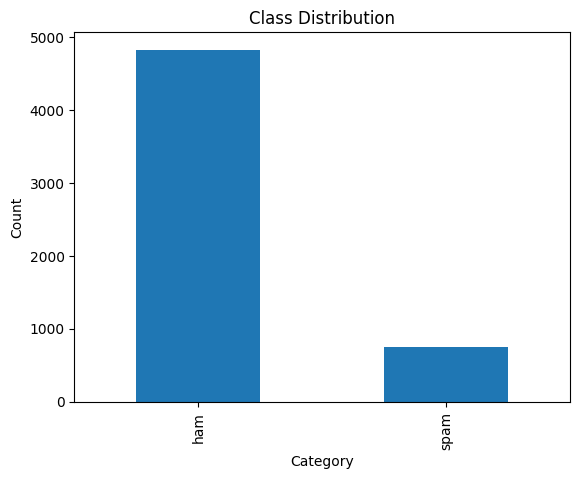

In [36]:
df["Category"].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

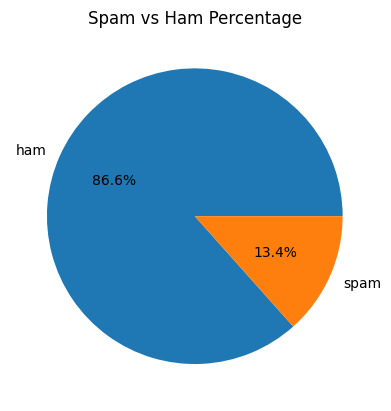

In [37]:
df["Category"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.title("Spam vs Ham Percentage")
plt.ylabel("")
plt.show()

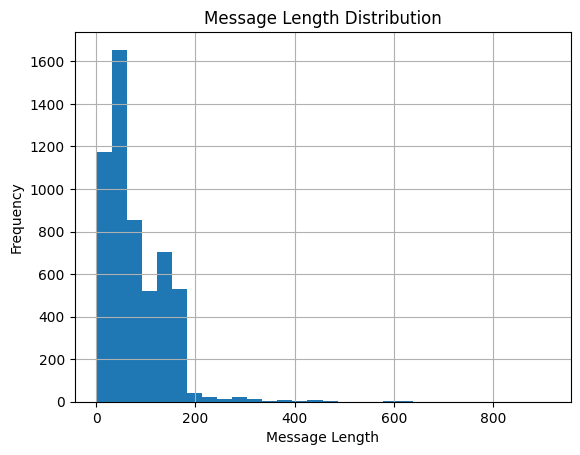

In [38]:
df["Message_Length"].hist(bins=30)

plt.title("Message Length Distribution")
plt.xlabel("Message Length")
plt.ylabel("Frequency")
plt.show()

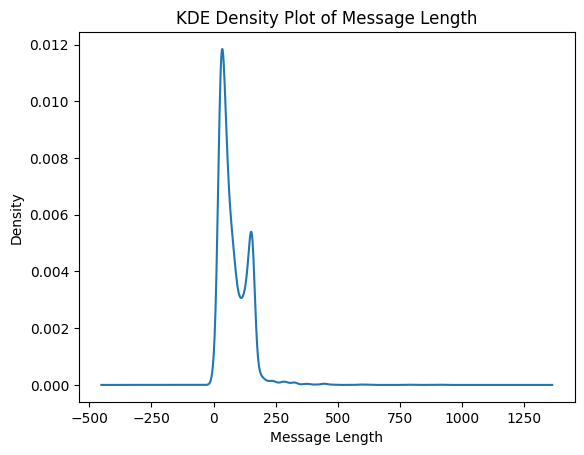

In [39]:
df["Message_Length"].plot(kind="kde")

plt.title("KDE Density Plot of Message Length")
plt.xlabel("Message Length")
plt.show()

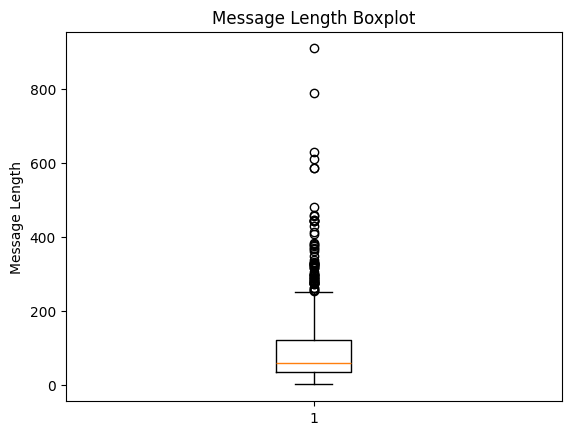

In [40]:
plt.boxplot(df["Message_Length"])

plt.title("Message Length Boxplot")
plt.ylabel("Message Length")
plt.show()

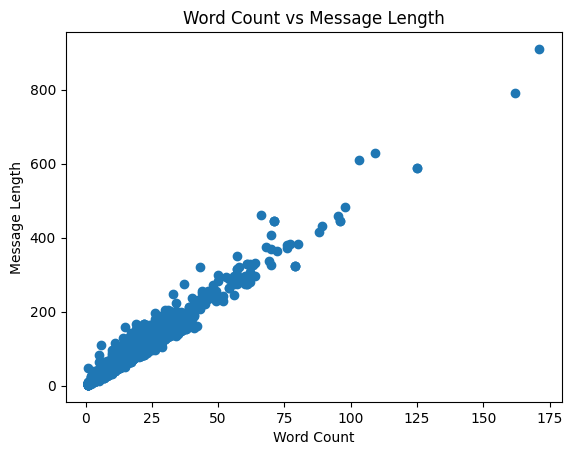

In [41]:
plt.scatter(df["Word_Count"], df["Message_Length"])

plt.title("Word Count vs Message Length")
plt.xlabel("Word Count")
plt.ylabel("Message Length")
plt.show()

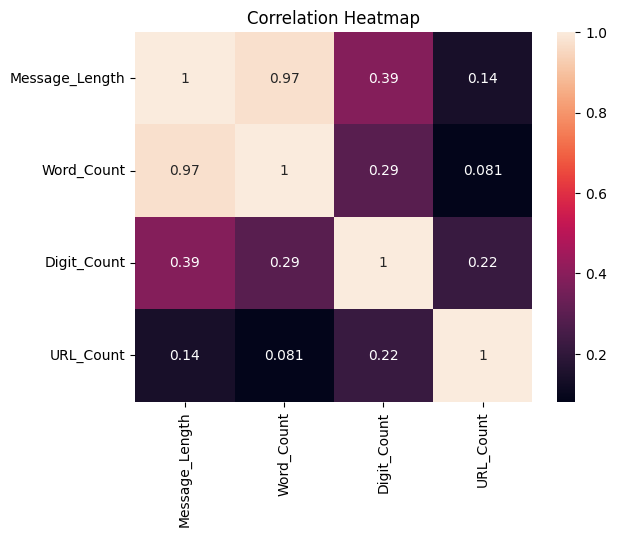

In [42]:
corr = df[features].corr()

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")
plt.show()

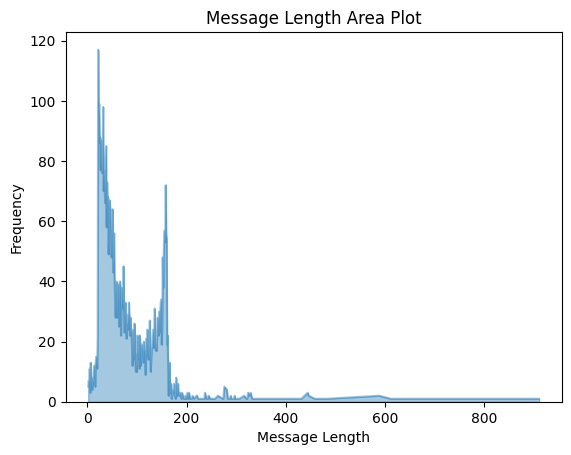

In [43]:
message_length_counts = df['Message_Length'].value_counts().sort_index()

message_length_counts.plot(kind='area', alpha=0.4)

plt.title('Message Length Area Plot')
plt.xlabel('Message Length')
plt.ylabel('Frequency')

plt.show()

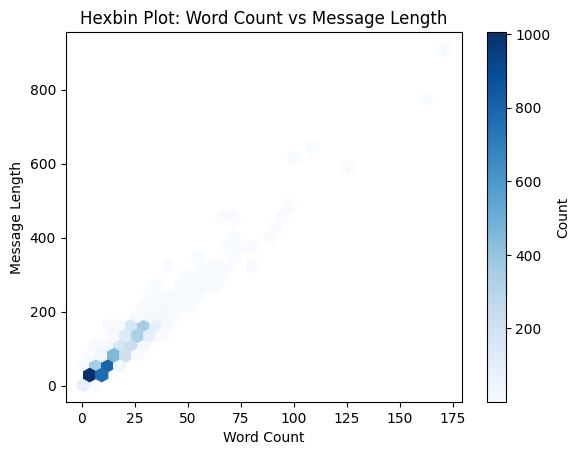

In [50]:
plt.hexbin(
    df['Word_Count'],
    df['Message_Length'],
    gridsize=30,
    mincnt=1,
    cmap='Blues'
)

plt.title('Hexbin Plot: Word Count vs Message Length')
plt.xlabel('Word Count')
plt.ylabel('Message Length')

plt.colorbar(label='Count')

plt.show()